In [ ]:
##Capital: $10,000 USD (Fixed starting balance).
#Risk per Trade: 1% of Capital ($100 loss max per trade).
#Reward per Trade: 2% of Capital ($200 gain max per trade).
#Logic: This means our Stop Loss and Take Profit levels are calculated based on the entry price to ensure that if hit, the PnL equals exactly $100 or $200.
#No Costs: Pure strategy performance first.

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime # Import datetime module

# ============================================================
# ⚙️  CONFIGURATION
# ============================================================
SYMBOL = 'BTC-USD'
START_DATE = '2024-06-01' # Modified START_DATE to a more recent date
END_DATE = datetime.date.today().strftime('%Y-%m-%d') # Set END_DATE to today's date
TIMEFRAME = '1h' # Hourly data

# Strategy Parameters
EMA_FAST = 9
EMA_MEDIUM = 21
EMA_SLOW = 55

# Account & Risk Parameters
INITIAL_CAPITAL = 10000.0
RISK_PERCENT = 0.01  # 1% Risk per trade ($100 on $10k)
RR_RATIO = 2.0       # 1:2 Risk-Reward ($200 Reward on $10k)

# Derived Values
RISK_AMOUNT = INITIAL_CAPITAL * RISK_PERCENT      # $100
REWARD_AMOUNT = RISK_AMOUNT * RR_RATIO            # $200

print(f"⚙️ Config Loaded: Risk=${RISK_AMOUNT}, Reward=${REWARD_AMOUNT}")

⚙️ Config Loaded: Risk=$100.0, Reward=$200.0


In [ ]:
#Cell 2: Data Acquisition
#Why this code?
#We fetch clean, hourly BTC data. We drop NaN values because EMAs cannot be calculated on missing data, and missing prices would break our PnL calculations.

In [ ]:
# ============================================================
# 📥 STEP 1: DATA ACQUISITION
# ============================================================
print("📥 Fetching data from Yahoo Finance...")

df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, interval=TIMEFRAME)

if df.empty:
    raise ValueError("No data found. Check dates or symbol.")

df.dropna(inplace=True)
df.reset_index(inplace=True)

# Flatten MultiIndex columns if they exist
# This converts columns like ('Close', 'BTC-USD') to 'Close'
if isinstance(df.columns, pd.MultiIndex):
    # This assumes the meaningful column name is in the first level of the MultiIndex
    # and the second level is often the ticker symbol or redundant.
    df.columns = df.columns.droplevel(1)

    # Handle cases where reset_index() might create a ('', 'Datetime') or similar if levels are empty
    # or if the Datetime column itself became part of a MultiIndex.
    # A more robust flattening method:
    df.columns = ['_'.join(col).strip() if isinstance(col, tuple) else str(col) for col in df.columns.values]

print(f"✅ Data Loaded: {len(df)} candles from {df['Datetime'].min()} to {df['Datetime'].max()}")

/tmp/ipykernel_20580/624799430.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, interval=TIMEFRAME)
[*********************100%***********************]  1 of 1 completed

📥 Fetching data from Yahoo Finance...
✅ Data Loaded: 17127 candles from 2024-06-01 00:00:00+00:00 to 2026-05-16 23:00:00+00:00


In [ ]:
 #Cell 3: Indicator Calculation
#Why this code?
#We calculate the three EMAs. These are the "eyes" of our strategy. We use ewm (Exponential Weighted Moving Average) which is the standard for trading strategies.

In [ ]:
# ============================================================
# 📊 STEP 2: INDICATOR CALCULATION
# ============================================================
print("📈 Calculating EMAs...")

df['EMA_9'] = df['Close'].ewm(span=EMA_FAST, adjust=False).mean()
df['EMA_21'] = df['Close'].ewm(span=EMA_MEDIUM, adjust=False).mean()
df['EMA_55'] = df['Close'].ewm(span=EMA_SLOW, adjust=False).mean()

# Drop rows where EMA_55 is NaN (first 54 candles)
df.dropna(subset=['EMA_55'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Indicators Ready. Valid Candles: {len(df)}")

📈 Calculating EMAs...
✅ Indicators Ready. Valid Candles: 17127


In [ ]:
#Cell 4: Signal Generation
#Why this code?
#We define the rules.
#Buy: EMA 9 > 21 AND 21 > 55.
#Sell: EMA 9 < 21 AND 21 < 55.
#We store these as True/False booleans. This separates "seeing a signal" from "taking a trade."

In [ ]:
# ============================================================
# 🧠 STEP 3: SIGNAL GENERATION
# ============================================================
print("🧠 Generating Signals...")

buy_condition = (df['EMA_9'] > df['EMA_21']) & (df['EMA_21'] > df['EMA_55'])
sell_condition = (df['EMA_9'] < df['EMA_21']) & (df['EMA_21'] < df['EMA_55'])

df['Signal_Buy'] = buy_condition
df['Signal_Sell'] = sell_condition

print(f"✅ Signals Generated. Buy: {buy_condition.sum()}, Sell: {sell_condition.sum()}")

🧠 Generating Signals...
✅ Signals Generated. Buy: 6948, Sell: 6314


In [ ]:
# ============================================================
# 🔍 INSPECT SIGNALS WITH DATES
# ============================================================
print("📅 Last 10 Candles & Signals:")

# Select Date and Signal columns, show last 10 rows
last_signals = df[['Datetime', 'Close', 'EMA_9', 'EMA_21', 'EMA_55', 'Signal_Buy', 'Signal_Sell']].tail(10)

# Format the Date column to be more readable if needed
# last_signals['Datetime'] = pd.to_datetime(last_signals['Datetime']).dt.strftime('%Y-%m-%d %H:%M')

print(last_signals.to_string())

📅 Last 10 Candles & Signals:
                       Datetime         Close         EMA_9        EMA_21        EMA_55  Signal_Buy  Signal_Sell
17117 2026-05-16 14:00:00+00:00  78094.593750  78213.499087  78657.131128  79399.323276       False         True
17118 2026-05-16 15:00:00+00:00  78201.429688  78211.085207  78615.703724  79356.541362       False         True
17119 2026-05-16 16:00:00+00:00  78177.843750  78204.436916  78575.898272  79314.445018       False         True
17120 2026-05-16 17:00:00+00:00  78169.609375  78197.471408  78538.962918  79273.558031       False         True
17121 2026-05-16 18:00:00+00:00  78196.937500  78197.364626  78507.869698  79235.107298       False         True
17122 2026-05-16 19:00:00+00:00  78234.398438  78204.771388  78483.008674  79199.367696       False         True
17123 2026-05-16 20:00:00+00:00  78205.187500  78204.854611  78457.752204  79163.861260       False         True
17124 2026-05-16 21:00:00+00:00  78232.343750  78210.352439  78437.

In [ ]:
#Cell 5: The Backtest Engine (Core Logic)
#Why this code?
#This is the most important part. We simulate trading day-by-day.
#Position Sizing: We calculate how much BTC to buy/sell so that if the Stop Loss is hit, we lose exactly $100.
#Formula: Position Size = Risk Amount / |Entry Price - SL Price|
#Dynamic SL/TP: We set SL at 1% distance and TP at 2% distance from entry.
#Execution: We enter at the Open of the next candle after the signal. We exit if the High/Low of any subsequent candle touches our SL or TP.
#One Trade at a Time: We ignore new signals while in_trade is True.

In [ ]:
# ============================================================
# 🤖 STEP 4: BACKTEST EXECUTION ENGINE
# ============================================================
print("⚙️ Running Simulation...")

trades = []
in_trade = False
trade_type = None
entry_price = 0.0
entry_date = None
sl_price = 0.0
tp_price = 0.0
position_size = 0.0 # How many BTC units we hold

for i in range(1, len(df)):
    current_row = df.iloc[i]
    prev_row = df.iloc[i-1]

    current_date = current_row['Datetime']
    current_open = current_row['Open']
    current_high = current_row['High']
    current_low = current_row['Low']

    # --- CHECK EXIT CONDITIONS ---
    if in_trade:
        exit_reason = None
        exit_price = 0.0

        if trade_type == 'BUY':
            if current_low <= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_high >= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        elif trade_type == 'SELL':
            if current_high >= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_low <= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        if exit_reason:
            # Calculate PnL: (Exit - Entry) * Position Size
            pnl = (exit_price - entry_price) * position_size if trade_type == 'BUY' else (entry_price - exit_price) * position_size

            trades.append({
                'Entry_Date': entry_date,
                'Exit_Date': current_date,
                'Type': trade_type,
                'Entry_Price': entry_price,
                'Exit_Price': exit_price,
                'Position_Size': position_size,
                'PnL': pnl,
                'Reason': exit_reason
            })
            in_trade = False
            trade_type = None

    # --- CHECK ENTRY CONDITIONS ---
    if not in_trade:
        # Use previous candle for signal, current candle for entry
        if prev_row['Signal_Buy']:
            in_trade = True
            trade_type = 'BUY'
            entry_price = current_open
            entry_date = current_date

            # Define SL/TP Prices (1% and 2% from entry)
            sl_price = entry_price * 0.99
            tp_price = entry_price * 1.02

            # Calculate Position Size to risk exactly $100
            # Risk = |Entry - SL| * Size  =>  Size = Risk / |Entry - SL|
            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

        elif prev_row['Signal_Sell']:
            in_trade = True
            trade_type = 'SELL'
            entry_price = current_open
            entry_date = current_date

            # Define SL/TP Prices
            sl_price = entry_price * 1.01
            tp_price = entry_price * 0.98

            # Calculate Position Size
            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

# Convert results to DataFrame
trades_df = pd.DataFrame(trades)
print(f"✅ Simulation Complete. Total Trades: {len(trades_df)}")

⚙️ Running Simulation...
✅ Simulation Complete. Total Trades: 1717


In [ ]:
#Cell 6: Performance Analysis
#Why this code?
#Raw numbers are hard to read. This cell calculates the key metrics:
#Net Profit: Sum of all PnL.
#Win Rate: Percentage of trades that were profitable.
#Profit Factor: Gross Profit / Gross Loss. (Aim for > 1.5).
#"Equity Curve: A list showing how our $10,000 grew over time


📊 BACKTEST RESULTS (NO COSTS)
Initial Capital: $10,000.00
Final Capital:   $30,900.00
Net Profit:      $20,900.00
Total Trades:    1717
Win Rate:        37.39%
Profit Factor:   1.19


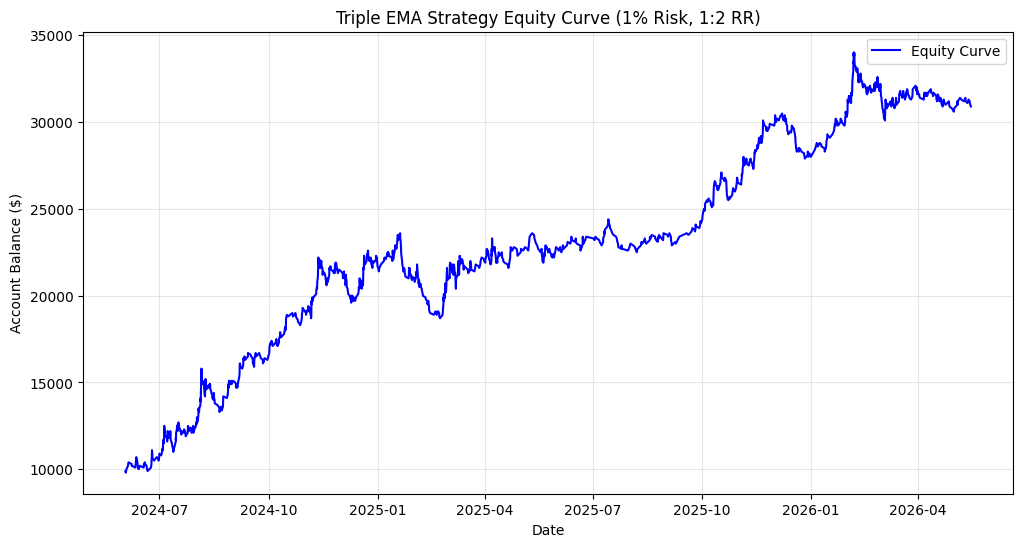

In [ ]:
# ============================================================
# 📈 STEP 5: PERFORMANCE ANALYSIS
# ============================================================
if not trades_df.empty:
    # Basic Metrics
    total_pnl = trades_df['PnL'].sum()
    winning_trades = trades_df[trades_df['PnL'] > 0]
    losing_trades = trades_df[trades_df['PnL'] < 0]

    win_rate = len(winning_trades) / len(trades_df) * 100
    gross_profit = winning_trades['PnL'].sum()
    gross_loss = abs(losing_trades['PnL'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else 0

    print("\n" + "="*40)
    print("📊 BACKTEST RESULTS (NO COSTS)")
    print("="*40)
    print(f"Initial Capital: ${INITIAL_CAPITAL:,.2f}")
    print(f"Final Capital:   ${INITIAL_CAPITAL + total_pnl:,.2f}")
    print(f"Net Profit:      ${total_pnl:,.2f}")
    print(f"Total Trades:    {len(trades_df)}")
    print(f"Win Rate:        {win_rate:.2f}%")
    print(f"Profit Factor:   {profit_factor:.2f}")
    print("="*40)

    # Plot Equity Curve
    trades_df['Cumulative_PnL'] = trades_df['PnL'].cumsum()
    equity_curve = INITIAL_CAPITAL + trades_df['Cumulative_PnL']

    plt.figure(figsize=(12, 6))
    plt.plot(trades_df['Exit_Date'], equity_curve, label='Equity Curve', color='blue')
    plt.title('Triple EMA Strategy Equity Curve (1% Risk, 1:2 RR)')
    plt.xlabel('Date')
    plt.ylabel('Account Balance ($)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ No trades were executed. Check your signal logic or data range.")

In [ ]:
 #Cell 9: The "Prop Firm Reality" Simulation
#Why this code?
#We are re-running the engine with exact prop firm costs.
#Entry Price Adjustment: We enter at Open + Spread (for buys) or Open - Spread (for sells). This simulates starting the trade immediately in the negative.
#Commission Deduction: We subtract 0.06% of the total position value from every trade's PnL.
#Slippage: We add a random penalty to simulate execution delay.

In [ ]:
# ============================================================
# 💸 STEP 6: PROP FIRM REALITY CHECK (EXACT COSTS)
# ============================================================
print("💸 Applying Prop Firm Costs: Comm 0.06%, Spread 0.03%, Slip 0.02%...")

# Cost Parameters (Based on PropFirmMatch Data)
COMMISSION_PCT = 0.0006      # 0.03% per side * 2 = 0.06% round turn
SPREAD_PCT = 0.0003          # 0.03% Spread (Realistic for BTC)
SLIPPAGE_PCT = 0.0002        # 0.02% Average Slippage

trades_prop = []
in_trade = False
trade_type = None
entry_price = 0.0
entry_date = None
sl_price = 0.0
tp_price = 0.0
position_size = 0.0

for i in range(1, len(df)):
    current_row = df.iloc[i]
    prev_row = df.iloc[i-1]

    current_date = current_row['Datetime']
    current_open = current_row['Open']
    current_high = current_row['High']
    current_low = current_row['Low']

    # --- CHECK EXIT CONDITIONS ---
    if in_trade:
        exit_reason = None
        exit_price = 0.0

        if trade_type == 'BUY':
            if current_low <= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_high >= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        elif trade_type == 'SELL':
            if current_high >= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_low <= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        if exit_reason:
            # Calculate Gross PnL (based on clean entry/exit prices)
            gross_pnl = (exit_price - entry_price) * position_size if trade_type == 'BUY' else (entry_price - exit_price) * position_size

            # Apply Costs
            # 1. Commission: 0.06% of Total Position Value (Entry Price * Size)
            cost_commission = (entry_price * position_size) * COMMISSION_PCT

            # 2. Slippage: Randomized between 0 and 0.04% (avg 0.02%)
            slip_factor = np.random.uniform(0, SLIPPAGE_PCT * 2)
            cost_slippage = (entry_price * position_size) * slip_factor

            # Total Net PnL
            net_pnl = gross_pnl - cost_commission - cost_slippage

            trades_prop.append({
                'Entry_Date': entry_date,
                'Exit_Date': current_date,
                'Type': trade_type,
                'Entry_Price': entry_price,
                'Exit_Price': exit_price,
                'Position_Size': position_size,
                'Gross_PnL': gross_pnl,
                'Costs': cost_commission + cost_slippage,
                'Net_PnL': net_pnl,
                'Reason': exit_reason
            })
            in_trade = False
            trade_type = None

    # --- CHECK ENTRY CONDITIONS (With Spread) ---
    if not in_trade:
        if prev_row['Signal_Buy']:
            in_trade = True
            trade_type = 'BUY'

            # Apply Spread: You buy slightly higher than market open
            entry_price = current_open * (1 + SPREAD_PCT)

            entry_date = current_date
            # SL/TP are calculated from the ACTUAL entry price (including spread)
            sl_price = entry_price * 0.99
            tp_price = entry_price * 1.02

            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

        elif prev_row['Signal_Sell']:
            in_trade = True
            trade_type = 'SELL'

            # Apply Spread: You sell slightly lower than market open
            entry_price = current_open * (1 - SPREAD_PCT)

            entry_date = current_date
            sl_price = entry_price * 1.01
            tp_price = entry_price * 0.98

            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

# Convert to DataFrame
prop_df = pd.DataFrame(trades_prop)
print(f"✅ Prop Firm Simulation Complete. Total Trades: {len(prop_df)}")

💸 Applying Prop Firm Costs: Comm 0.06%, Spread 0.03%, Slip 0.02%...
✅ Prop Firm Simulation Complete. Total Trades: 1739



📊 PROP FIRM REALITY CHECK (BTC 1:5 Lev, 0.06% Comm)
Metric                    | Ideal (No Costs) | Prop Firm (Real)
------------------------------------------------------------
Net Profit                | $20,900.00      | $-906.19       
Win Rate                  | 37.39         % | 35.83         %
Total Fees Paid           | $0.00           | $13,906.19     
Return on Capital         | 209.00        % | -9.06         %


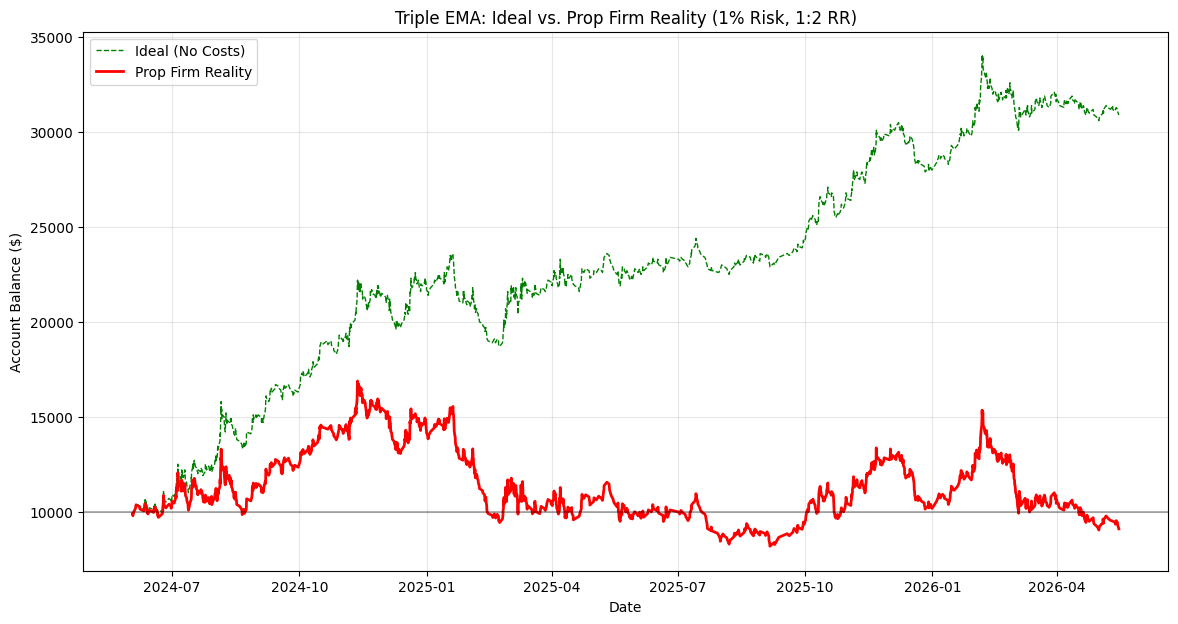

In [ ]:
# ============================================================
# 📊 STEP 7: FINAL PROP FIRM ANALYSIS
# ============================================================
if not prop_df.empty:
    total_net_pnl = prop_df['Net_PnL'].sum()
    total_costs = prop_df['Costs'].sum()
    win_rate_prop = len(prop_df[prop_df['Net_PnL'] > 0]) / len(prop_df) * 100

    # Previous No-Cost Stats
    total_gross_pnl = trades_df['PnL'].sum()
    win_rate_no_cost = len(trades_df[trades_df['PnL'] > 0]) / len(trades_df) * 100

    print("\n" + "="*60)
    print("📊 PROP FIRM REALITY CHECK (BTC 1:5 Lev, 0.06% Comm)")
    print("="*60)
    print(f"{'Metric':<25} | {'Ideal (No Costs)':<15} | {'Prop Firm (Real)':<15}")
    print("-" * 60)
    print(f"{'Net Profit':<25} | ${total_gross_pnl:<14,.2f} | ${total_net_pnl:<14,.2f}")
    print(f"{'Win Rate':<25} | {win_rate_no_cost:<14.2f}% | {win_rate_prop:<14.2f}%")
    print(f"{'Total Fees Paid':<25} | {'$0.00':<15} | ${total_costs:<14,.2f}")
    print(f"{'Return on Capital':<25} | {(total_gross_pnl/10000)*100:<14.2f}% | {(total_net_pnl/10000)*100:<14.2f}%")
    print("="*60)

    # Plot Comparison
    trades_df['Cumulative_Gross'] = trades_df['PnL'].cumsum()
    prop_df['Cumulative_Net'] = prop_df['Net_PnL'].cumsum()

    plt.figure(figsize=(14, 7))
    plt.plot(trades_df['Exit_Date'], INITIAL_CAPITAL + trades_df['Cumulative_Gross'], label='Ideal (No Costs)', color='green', linestyle='--', linewidth=1)
    plt.plot(prop_df['Exit_Date'], INITIAL_CAPITAL + prop_df['Cumulative_Net'], label='Prop Firm Reality', color='red', linewidth=2)

    plt.axhline(y=INITIAL_CAPITAL, color='black', linestyle='-', alpha=0.3)
    plt.title('Triple EMA: Ideal vs. Prop Firm Reality (1% Risk, 1:2 RR)')
    plt.xlabel('Date')
    plt.ylabel('Account Balance ($)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ No trades executed.")

⚙  Config Loaded: Risk=$100.0, Reward=$200.0
∣Ȅ Fetching data from Yahoo Finance...


/tmp/ipykernel_18639/3511205906.py:38: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, interval=TIMEFRAME)
[*********************100%***********************]  1 of 1 completed


✅ Data Loaded: 17327 candles
↗  Calculating EMAs...
✅ Indicators Ready. Valid Candles: 17327
ᐛ  Generating Signals (SHIFTED)...
✅ Signals Generated & Shifted. Buy: 6988, Sell: 6395
⚙  Running Simulation (Shifted Signals, No Costs)...
✅ Simulation Complete. Total Trades: 1741

📊 BACKTEST RESULTS (SHIFTED SIGNALS, NO COSTS)
Initial Capital: $10,000.00
Final Capital:   $26,100.00
Net Profit:      $16,100.00
Total Trades:    1741
Win Rate:        36.42%
Profit Factor:   1.15


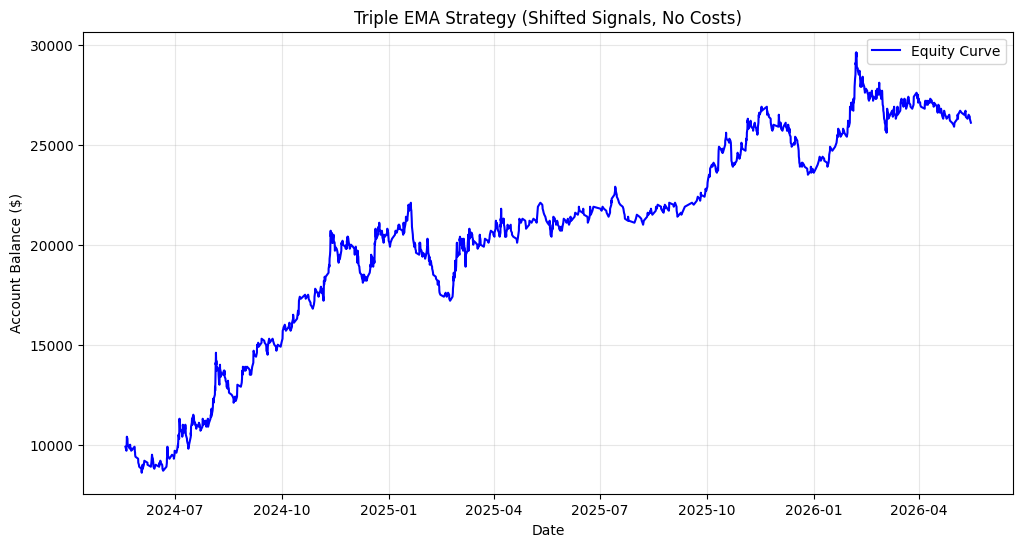

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date, timedelta # Import timedelta

# ============================================================
# ⚙  CONFIGURATION
# ============================================================
SYMBOL = 'BTC-USD'
# Adjust START_DATE to be within the last 730 days from today
END_DATE = date.today()
START_DATE = (END_DATE - timedelta(days=729)).strftime('%Y-%m-%d') # Approximately 2 years of data
END_DATE = END_DATE.strftime('%Y-%m-%d') # Convert to string after calculation
TIMEFRAME = '1h'

# Strategy Parameters
EMA_FAST = 9
EMA_MEDIUM = 21
EMA_SLOW = 55

# Account & Risk Parameters
INITIAL_CAPITAL = 10000.0
RISK_PERCENT = 0.01  # 1% Risk per trade ($100)
RR_RATIO = 2.0       # 1:2 Risk-Reward ($200)

# Derived Values
RISK_AMOUNT = INITIAL_CAPITAL * RISK_PERCENT
REWARD_AMOUNT = RISK_AMOUNT * RR_RATIO

print(f"⚙  Config Loaded: Risk=${RISK_AMOUNT}, Reward=${REWARD_AMOUNT}")

# ============================================================
# ∣Ȅ STEP 1: DATA ACQUISITION & CLEANING
# ============================================================
print("∣Ȅ Fetching data from Yahoo Finance...")

df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, interval=TIMEFRAME)

if df.empty:
    raise ValueError("No data found.")

# Robust Column Flattening for yfinance
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
else:
    df.columns = [str(col) for col in df.columns.values]

# Ensure standard column names exist
required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
for col in required_cols:
    matching_col = [c for c in df.columns if col in c]
    if matching_col:
        df[col] = df[matching_col[0]]

df.dropna(inplace=True)
df.reset_index(inplace=True)
if 'index' in df.columns:
    df.rename(columns={'index': 'Datetime'}, inplace=True)

print(f"✅ Data Loaded: {len(df)} candles")

# ============================================================
# ↗  STEP 2: INDICATOR CALCULATION
# ============================================================
print("↗  Calculating EMAs...")

df['EMA_9'] = df['Close'].ewm(span=EMA_FAST, adjust=False).mean()
df['EMA_21'] = df['Close'].ewm(span=EMA_MEDIUM, adjust=False).mean()
df['EMA_55'] = df['Close'].ewm(span=EMA_SLOW, adjust=False).mean()

df.dropna(subset=['EMA_55'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Indicators Ready. Valid Candles: {len(df)}")

# ============================================================
# ᐛ  STEP 3: SIGNAL GENERATION (SHIFTED FOR PROFESSIONAL SAFETY)
# ============================================================
print("ᐛ  Generating Signals (SHIFTED)...")

buy_condition = (df['EMA_9'] > df['EMA_21']) & (df['EMA_21'] > df['EMA_55'])
sell_condition = (df['EMA_9'] < df['EMA_21']) & (df['EMA_21'] < df['EMA_55'])

# Shift signals by 1: signal generated at close of candle i is available at open of candle i+1
df['Signal_Buy'] = buy_condition.shift(1)
df['Signal_Sell'] = sell_condition.shift(1)

# Drop first row (NaN from shift) to keep alignment clean
df.dropna(subset=['Signal_Buy', 'Signal_Sell'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Signals Generated & Shifted. Buy: {df['Signal_Buy'].sum()}, Sell: {df['Signal_Sell'].sum()}")

# ============================================================
# ᾑ6 STEP 4: BACKTEST EXECUTION ENGINE (UPDATED FOR SHIFTED SIGNALS)
# ============================================================
print("⚙  Running Simulation (Shifted Signals, No Costs)...")

trades = []
in_trade = False
trade_type = None
entry_price = 0.0
entry_date = None
sl_price = 0.0
tp_price = 0.0
position_size = 0.0

for i in range(len(df)):  # Start from 0 since we dropped NaNs
    current_row = df.iloc[i]

    current_date = current_row['Datetime']
    current_open = current_row['Open']
    current_high = current_row['High']
    current_low = current_row['Low']

    # --- CHECK EXIT CONDITIONS ---
    if in_trade:
        exit_reason = None
        exit_price = 0.0

        if trade_type == 'BUY':
            if current_low <= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_high >= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        elif trade_type == 'SELL':
            if current_high >= sl_price:
                exit_reason = 'SL_HIT'
                exit_price = sl_price
            elif current_low <= tp_price:
                exit_reason = 'TP_HIT'
                exit_price = tp_price

        if exit_reason:
            pnl = (exit_price - entry_price) * position_size if trade_type == 'BUY' else (entry_price - exit_price) * position_size

            trades.append({
                'Entry_Date': entry_date,
                'Exit_Date': current_date,
                'Type': trade_type,
                'Entry_Price': entry_price,
                'Exit_Price': exit_price,
                'Position_Size': position_size,
                'PnL': pnl,
                'Reason': exit_reason
            })
            in_trade = False
            trade_type = None

    # --- CHECK ENTRY CONDITIONS (Using CURRENT row since signals are shifted) ---
    if not in_trade:
        # Signal_Buy is now True if signal was generated at PREVIOUS candle's close
        if current_row['Signal_Buy']:
            in_trade = True
            trade_type = 'BUY'
            entry_price = current_open
            entry_date = current_date

            sl_price = entry_price * 0.99
            tp_price = entry_price * 1.02

            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

        elif current_row['Signal_Sell']:
            in_trade = True
            trade_type = 'SELL'
            entry_price = current_open
            entry_date = current_date

            sl_price = entry_price * 1.01
            tp_price = entry_price * 0.98

            risk_per_unit = abs(entry_price - sl_price)
            position_size = RISK_AMOUNT / risk_per_unit

trades_df = pd.DataFrame(trades)
print(f"✅ Simulation Complete. Total Trades: {len(trades_df)}")

# ============================================================
# ↗  STEP 5: PERFORMANCE ANALYSIS
# ============================================================
if not trades_df.empty:
    total_pnl = trades_df['PnL'].sum()
    winning_trades = trades_df[trades_df['PnL'] > 0]
    losing_trades = trades_df[trades_df['PnL'] < 0]

    win_rate = len(winning_trades) / len(trades_df) * 100
    gross_profit = winning_trades['PnL'].sum()
    gross_loss = abs(losing_trades['PnL'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else 0

    print("\n" + "="*40)
    print("📊 BACKTEST RESULTS (SHIFTED SIGNALS, NO COSTS)")
    print("="*40)
    print(f"Initial Capital: ${INITIAL_CAPITAL:,.2f}")
    print(f"Final Capital:   ${INITIAL_CAPITAL + total_pnl:,.2f}")
    print(f"Net Profit:      ${total_pnl:,.2f}")
    print(f"Total Trades:    {len(trades_df)}")
    print(f"Win Rate:        {win_rate:.2f}%")
    print(f"Profit Factor:   {profit_factor:.2f}")
    print("="*40)

    # Plot Equity Curve
    trades_df['Cumulative_PnL'] = trades_df['PnL'].cumsum()
    equity_curve = INITIAL_CAPITAL + trades_df['Cumulative_PnL']

    plt.figure(figsize=(12, 6))
    plt.plot(trades_df['Exit_Date'], equity_curve, label='Equity Curve', color='blue')
    plt.title('Triple EMA Strategy (Shifted Signals, No Costs)')
    plt.xlabel('Date')
    plt.ylabel('Account Balance ($)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

else:
    print("❌ No trades were executed.")

In [ ]:
option 1: wider sl from 1% to 1.5% filter noise
option 2 : add trend filter to reduce frequency which will directly reduce costs
option  3: higher rr instead of 1:2 try 1:3 which will cover part of costs
there is many options to optimize your strategy we gonna discover it in next video part 3
rember trade systematic verify everything .
Dont forget to like subscribe thanks

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ⚙️  GLOBAL CONFIGURATION
# ============================================================
SYMBOL = 'BTC-USD'
START_DATE = '2024-06-01'
END_DATE = date.today().strftime('%Y-%m-%d')
TIMEFRAME = '1h'
INITIAL_CAPITAL = 10000.0
RISK_PERCENT = 0.01  # 1% fixed risk per trade

# EMA Parameters
EMA_FAST, EMA_MEDIUM, EMA_SLOW = 9, 21, 55

# Realistic Prop Firm Costs
COMMISSION_PCT = 0.0006   # 0.06% round turn
SPREAD_PCT = 0.0003       # 0.03% average
SLIPPAGE_PCT = 0.0002     # 0.02% average

print("⚙️ Configuration Loaded: 1% Risk, BTC-USD 1H, Realistic Costs")

⚙️ Configuration Loaded: 1% Risk, BTC-USD 1H, Realistic Costs


In [ ]:
# ============================================================
# 📥 STEP 1: DATA ACQUISITION
# ============================================================
print("📥 Fetching hourly BTC data...")
df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, interval=TIMEFRAME)

if df.empty:
    raise ValueError("No data found. Check dates or symbol.")

# Clean column names (yfinance sometimes returns MultiIndex)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
else:
    df.columns = [str(col) for col in df.columns.values]

# Ensure standard OHLCV columns exist
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    match = [c for c in df.columns if col in c]
    if match: df[col] = df[match[0]]

df.dropna(inplace=True)
df.reset_index(inplace=True)
if 'index' in df.columns:
    df.rename(columns={'index': 'Datetime'}, inplace=True)

print(f"✅ Data Loaded: {len(df)} candles from {df['Datetime'].min().date()} to {df['Datetime'].max().date()}")

📥 Fetching hourly BTC data...


[*********************100%***********************]  1 of 1 completed

✅ Data Loaded: 17319 candles from 2024-06-01 to 2026-05-24


In [ ]:
# ============================================================
# 📊 STEP 2: INDICATOR CALCULATION
# ============================================================
print("📈 Calculating EMAs...")
df['EMA_9'] = df['Close'].ewm(span=EMA_FAST, adjust=False).mean()
df['EMA_21'] = df['Close'].ewm(span=EMA_MEDIUM, adjust=False).mean()
df['EMA_55'] = df['Close'].ewm(span=EMA_SLOW, adjust=False).mean()

# Drop initial NaNs where EMA_55 is undefined
df.dropna(subset=['EMA_55'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Indicators Ready. Valid Candles: {len(df)}")

📈 Calculating EMAs...
✅ Indicators Ready. Valid Candles: 17319


In [ ]:
# ============================================================
# 🧠 STEP 3: SIGNAL GENERATION (SHIFTED)
# ============================================================
print("🧠 Generating Signals (Shifted to prevent look-ahead bias)...")

buy_condition = (df['EMA_9'] > df['EMA_21']) & (df['EMA_21'] > df['EMA_55'])
sell_condition = (df['EMA_9'] < df['EMA_21']) & (df['EMA_21'] < df['EMA_55'])

# Shift signals: signal at close of candle i becomes tradable at open of candle i+1
df['Signal_Buy'] = buy_condition.shift(1)
df['Signal_Sell'] = sell_condition.shift(1)

df.dropna(subset=['Signal_Buy', 'Signal_Sell'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Signals Generated. Buy: {df['Signal_Buy'].sum()}, Sell: {df['Signal_Sell'].sum()}")

🧠 Generating Signals (Shifted to prevent look-ahead bias)...
✅ Signals Generated. Buy: 6994, Sell: 6418


In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ⚙️  GLOBAL CONFIGURATION
# ============================================================
SYMBOL = 'BTC-USD'
START_DATE = '2024-06-01'
END_DATE = date.today().strftime('%Y-%m-%d')
TIMEFRAME = '1h'
INITIAL_CAPITAL = 10000.0
RISK_PERCENT = 0.01  # 1% fixed risk per trade

# EMA Parameters
EMA_FAST, EMA_MEDIUM, EMA_SLOW = 9, 21, 55

# Realistic Prop Firm Costs
COMMISSION_PCT = 0.0006   # 0.06% round turn
SPREAD_PCT = 0.0003       # 0.03% average
SLIPPAGE_PCT = 0.0002     # 0.02% average

print("⚙️ Configuration Loaded: 1% Risk, BTC-USD 1H, Realistic Costs")


# ============================================================
# 🧠 STEP 4: BACKTEST ENGINE (PARAMETERIZED)
# ============================================================
def run_optimization_test(df, rr_ratio=2.0, sl_pct=0.01, apply_costs=False, test_name="Test"):
    """
    Runs the backtest with configurable Risk-Reward and cost modeling.
    Returns trades DataFrame and performance metrics.
    """
    # sl_pct is now a parameter with a default value, no need to redefine here
    tp_pct = sl_pct * rr_ratio

    trades = []
    in_trade = False
    trade_type = None
    entry_price = 0.0
    entry_date = None
    sl_price = 0.0
    tp_price = 0.0
    position_size = 0.0

    risk_amount = INITIAL_CAPITAL * RISK_PERCENT

    for i in range(len(df)):
        row = df.iloc[i]
        dt, o, h, l = row['Datetime'], row['Open'], row['High'], row['Low']

        # --- EXIT LOGIC ---
        if in_trade:
            exit_reason, exit_price = None, 0.0
            if trade_type == 'BUY':
                if l <= sl_price: exit_reason, exit_price = 'SL', sl_price
                elif h >= tp_price: exit_reason, exit_price = 'TP', tp_price
            else:  # SELL
                if h >= sl_price: exit_reason, exit_price = 'SL', sl_price
                elif l <= tp_price: exit_reason, exit_price = 'TP', tp_price

            if exit_reason:
                gross_pnl = (exit_price - entry_price) * position_size if trade_type == 'BUY' else (entry_price - exit_price) * position_size
                costs = 0.0

                if apply_costs:
                    # Commission on full position value
                    costs += (entry_price * position_size) * COMMISSION_PCT
                    # Random slippage impact
                    slip_factor = np.random.uniform(0, SLIPPAGE_PCT * 2)
                    costs += (entry_price * position_size) * slip_factor

                net_pnl = gross_pnl - costs
                trades.append({
                    'Entry_Date': entry_date, 'Exit_Date': dt,
                    'Type': trade_type, 'Entry_Price': entry_price,
                    'Exit_Price': exit_price, 'Gross_PnL': gross_pnl,
                    'Costs': costs, 'Net_PnL': net_pnl, 'Reason': exit_reason
                })
                in_trade = False
                trade_type = None

        # --- ENTRY LOGIC (One trade at a time) ---
        if not in_trade:
            if row['Signal_Buy']:
                in_trade = True
                trade_type = 'BUY'
                # Apply spread to entry if modeling costs
                entry_price = o * (1 + SPREAD_PCT) if apply_costs else o
                entry_date = dt
                sl_price = entry_price * (1 - sl_pct)
                tp_price = entry_price * (1 + tp_pct)

            elif row['Signal_Sell']:
                in_trade = True
                trade_type = 'SELL'
                entry_price = o * (1 - SPREAD_PCT) if apply_costs else o
                entry_date = dt
                sl_price = entry_price * (1 + sl_pct)
                tp_price = entry_price * (1 - tp_pct)

            if in_trade:
                risk_per_unit = abs(entry_price - sl_price)
                position_size = risk_amount / risk_per_unit

    if not trades:
        return pd.DataFrame(), {}

    trades_df = pd.DataFrame(trades)

    gross_profit = trades_df[trades_df['Net_PnL'] > 0]['Net_PnL'].sum()
    gross_loss = abs(trades_df[trades_df['Net_PnL'] < 0]['Net_PnL'].sum())

    metrics = {
        'Net_Profit': trades_df['Net_PnL'].sum(),
        'Total_Trades': len(trades_df),
        'Win_Rate': (trades_df['Net_PnL'] > 0).mean() * 100,
        'Profit_Factor': gross_profit / gross_loss if gross_loss > 0 else 0,
        'Total_Costs': trades_df['Costs'].sum(),
        'Avg_Trade': trades_df['Net_PnL'].mean()
    }
    return trades_df, metrics

⚙️ Configuration Loaded: 1% Risk, BTC-USD 1H, Realistic Costs


In [ ]:
# ============================================================
#  STEP 5: RUN OPTIMIZATION 1 (RR 1:2 vs 1:3)
# ============================================================
print(" Running Optimization 1: Risk-Reward Comparison...")

# Create independent copies to avoid data mutation
df_raw_1h = df.copy()
df_cost_1h = df.copy()
df_raw_1h_3 = df.copy()
df_cost_1h_3 = df.copy()

results = {}

# 1. Baseline: 1:2 RR, No Costs
results['1:2_Raw'], metrics_12_raw = run_optimization_test(df_raw_1h, rr_ratio=2.0, apply_costs=False, test_name="1:2 RR (RAW)")
# 2. Baseline: 1:2 RR, With Costs
results['1:2_Cost'], metrics_12_cost = run_optimization_test(df_cost_1h, rr_ratio=2.0, apply_costs=True, test_name="1:2 RR (COSTS)")
# 3. Optimized: 1:3 RR, No Costs
results['1:3_Raw'], metrics_13_raw = run_optimization_test(df_raw_1h_3, rr_ratio=3.0, apply_costs=False, test_name="1:3 RR (RAW)")
# 4. Optimized: 1:3 RR, With Costs
results['1:3_Cost'], metrics_13_cost = run_optimization_test(df_cost_1h_3, rr_ratio=3.0, apply_costs=True, test_name="1:3 RR (COSTS)")

print("✅ All 4 scenarios complete.")

 Running Optimization 1: Risk-Reward Comparison...
✅ All 4 scenarios complete.



📈 OPTIMIZATION 1 RESULTS: RR 1:2 vs 1:3
      Scenario Net_Profit  Total_Trades Win_Rate Profit_Factor Total_Costs Avg_Trade
  1:2 RR (RAW) $21,100.00          1724    37.4%          1.20       $0.00    $12.24
1:2 RR (COSTS)   $-745.03          1746    35.9%          0.99  $13,945.03    $-0.43
  1:3 RR (RAW) $13,500.00          1217    27.8%          1.15       $0.00    $11.09
1:3 RR (COSTS) $-1,222.13          1252    26.8%          0.99  $10,022.13    $-0.98


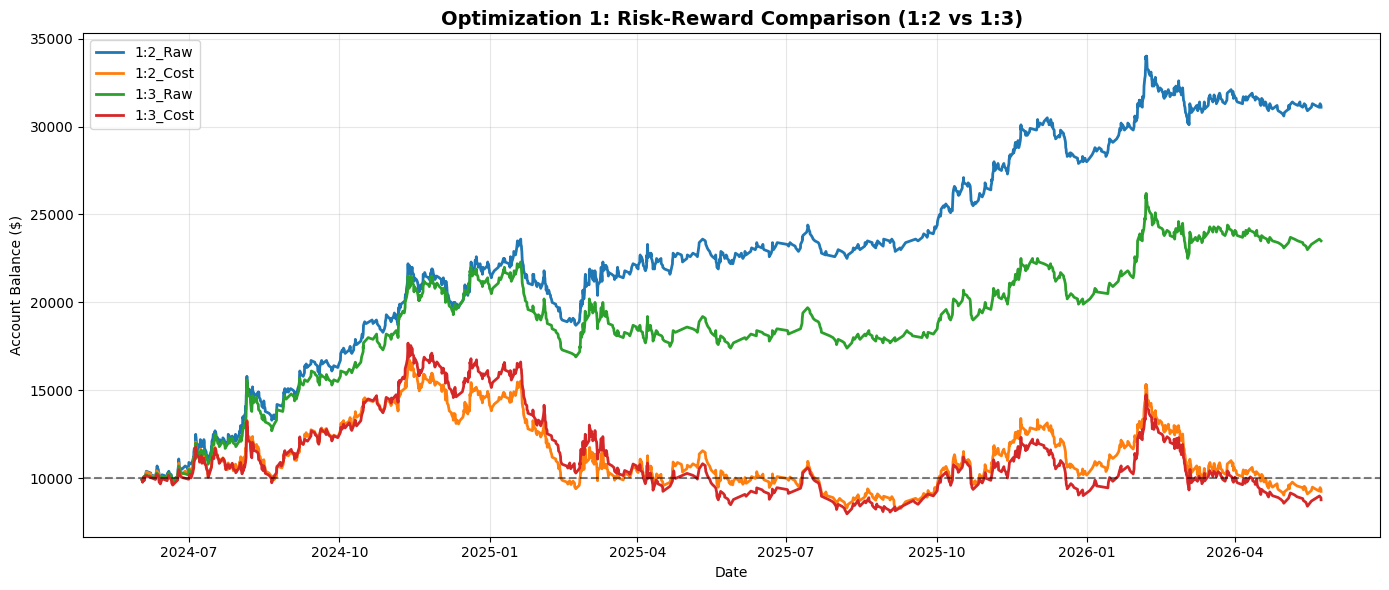

In [ ]:
# ============================================================
# 📊 STEP 6: ANALYSIS & VISUALIZATION
# ============================================================
print("\n" + "="*70)
print("📈 OPTIMIZATION 1 RESULTS: RR 1:2 vs 1:3")
print("="*70)

# Build comparison DataFrame
comp_data = []
for name, m in [('1:2 RR (RAW)', metrics_12_raw),
                ('1:2 RR (COSTS)', metrics_12_cost),
                ('1:3 RR (RAW)', metrics_13_raw),
                ('1:3 RR (COSTS)', metrics_13_cost)]:
    comp_data.append({
        'Scenario': name,
        'Net_Profit': f"${m['Net_Profit']:,.2f}",
        'Total_Trades': m['Total_Trades'],
        'Win_Rate': f"{m['Win_Rate']:.1f}%",
        'Profit_Factor': f"{m['Profit_Factor']:.2f}",
        'Total_Costs': f"${m['Total_Costs']:,.2f}",
        'Avg_Trade': f"${m['Avg_Trade']:.2f}"
    })

comp_df = pd.DataFrame(comp_data)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(comp_df.to_string(index=False))
print("="*70)

# Plot Equity Curves
plt.figure(figsize=(14, 6))

for name, df_trades in results.items():
    if not df_trades.empty:
        equity = INITIAL_CAPITAL + df_trades['Net_PnL'].cumsum()
        plt.plot(df_trades['Exit_Date'], equity, label=name, linewidth=2)

plt.axhline(INITIAL_CAPITAL, color='black', linestyle='--', alpha=0.5)
plt.title('Optimization 1: Risk-Reward Comparison (1:2 vs 1:3)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Account Balance ($)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 🧠 STEP 3B: SIGNAL GENERATION WITH TREND FILTER
# ============================================================
print("🧠 Generating Signals WITH 200 EMA Trend Filter...")

# Calculate 200 EMA for trend direction
df['EMA_200'] = df['Close'].ewm(span=200, adjust=False).mean()

# Base signals
buy_condition = (df['EMA_9'] > df['EMA_21']) & (df['EMA_21'] > df['EMA_55'])
sell_condition = (df['EMA_9'] < df['EMA_21']) & (df['EMA_21'] < df['EMA_55'])

# OPTIMIZATION 2: Only trade WITH the trend
# Buy only if price is ABOVE 200 EMA (uptrend)
# Sell only if price is BELOW 200 EMA (downtrend)
buy_condition = buy_condition & (df['Close'] > df['EMA_200'])
sell_condition = sell_condition & (df['Close'] < df['EMA_200'])

# Shift signals to prevent look-ahead bias
df['Signal_Buy'] = buy_condition.shift(1)
df['Signal_Sell'] = sell_condition.shift(1)

# Drop NaNs from shift and initial EMA_200 calculation
df.dropna(subset=['Signal_Buy', 'Signal_Sell', 'EMA_200'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Signals Generated WITH Trend Filter. Buy: {df['Signal_Buy'].sum()}, Sell: {df['Signal_Sell'].sum()}")
print(f"📉 Expected trade reduction: ~30-50% fewer signals")

🧠 Generating Signals WITH 200 EMA Trend Filter...
✅ Signals Generated WITH Trend Filter. Buy: 6146, Sell: 5502
📉 Expected trade reduction: ~30-50% fewer signals


In [ ]:
# ============================================================
# 🤖 STEP 5B: RUN OPTIMIZATION 2 (TREND FILTER)
# ============================================================
print(" Running Optimization 2: 200 EMA Trend Filter...")

# Create independent data copies
df_trend_raw = df.copy()
df_trend_cost = df.copy()

results_trend = {}

# 1. Trend Filter + 1:2 RR + NO Costs
results_trend['Trend_1:2_Raw'], metrics_trend_raw = run_optimization_test(
    df_trend_raw, rr_ratio=2.0, apply_costs=False, test_name="Trend Filter + 1:2 RR (RAW)"
)

# 2. Trend Filter + 1:2 RR + WITH Costs
results_trend['Trend_1:2_Cost'], metrics_trend_cost = run_optimization_test(
    df_trend_cost, rr_ratio=2.0, apply_costs=True, test_name="Trend Filter + 1:2 RR (COSTS)"
)

print("✅ Trend Filter tests complete.")

 Running Optimization 2: 200 EMA Trend Filter...
✅ Trend Filter tests complete.



📈 OPTIMIZATION 2 RESULTS: 200 EMA Trend Filter Impact
                     Strategy Condition  Net_Profit  Total_Trades  Win_Rate  Profit_Factor  Total_Costs
Baseline (No Filter) + 1:2 RR       RAW   21,100.00          1724     37.41           1.20         0.00
Baseline (No Filter) + 1:2 RR     COSTS     -745.03          1746     35.85           0.99    13,945.03
        Trend Filter + 1:2 RR       RAW   20,600.00          1552     37.76           1.21         0.00
        Trend Filter + 1:2 RR     COSTS      481.88          1571     36.09           1.00    12,518.12


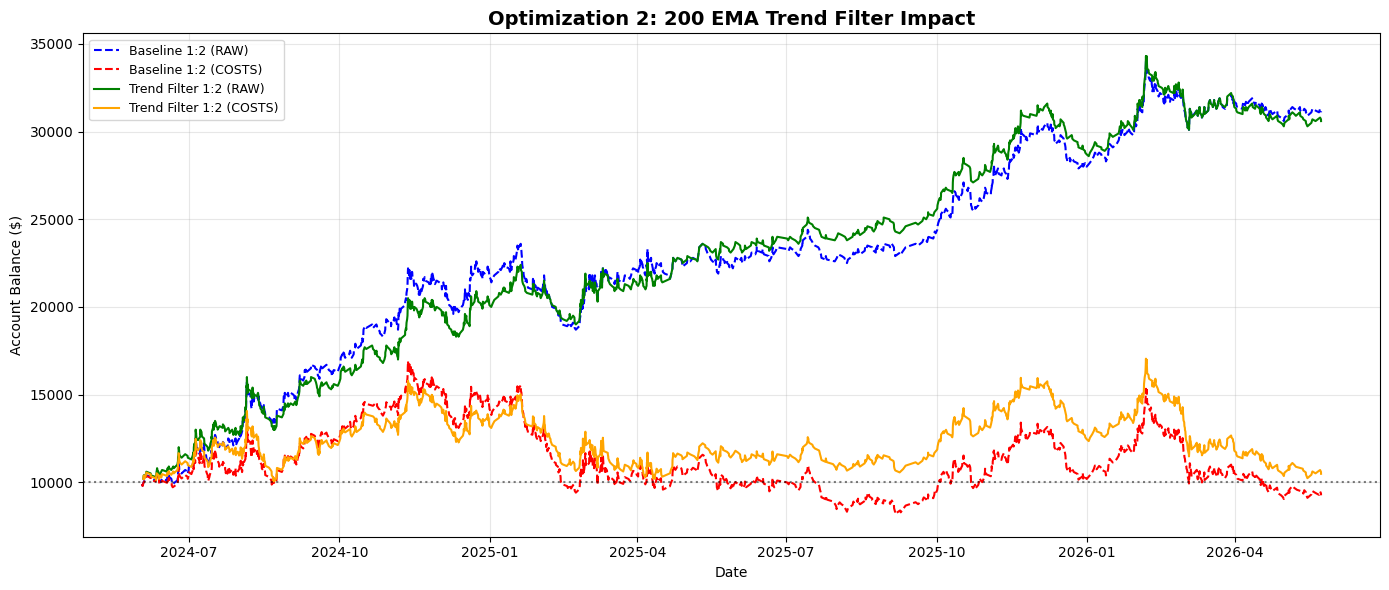

In [ ]:
# ============================================================
# 📊 STEP 6B: ANALYSIS - TREND FILTER IMPACT
# ============================================================
print("\n" + "="*80)
print("📈 OPTIMIZATION 2 RESULTS: 200 EMA Trend Filter Impact")
print("="*80)

# Combine baseline and trend filter results for direct comparison
comparison_data = []

# Baseline (from Optimization 1)
comparison_data.append({
    'Strategy': 'Baseline (No Filter) + 1:2 RR',
    'Condition': 'RAW',
    'Net_Profit': metrics_12_raw['Net_Profit'],
    'Total_Trades': metrics_12_raw['Total_Trades'],
    'Win_Rate': metrics_12_raw['Win_Rate'],
    'Profit_Factor': metrics_12_raw['Profit_Factor'],
    'Total_Costs': 0
})
comparison_data.append({
    'Strategy': 'Baseline (No Filter) + 1:2 RR',
    'Condition': 'COSTS',
    'Net_Profit': metrics_12_cost['Net_Profit'],
    'Total_Trades': metrics_12_cost['Total_Trades'],
    'Win_Rate': metrics_12_cost['Win_Rate'],
    'Profit_Factor': metrics_12_cost['Profit_Factor'],
    'Total_Costs': metrics_12_cost['Total_Costs']
})

# Trend Filter results
comparison_data.append({
    'Strategy': 'Trend Filter + 1:2 RR',
    'Condition': 'RAW',
    'Net_Profit': metrics_trend_raw['Net_Profit'],
    'Total_Trades': metrics_trend_raw['Total_Trades'],
    'Win_Rate': metrics_trend_raw['Win_Rate'],
    'Profit_Factor': metrics_trend_raw['Profit_Factor'],
    'Total_Costs': 0
})
comparison_data.append({
    'Strategy': 'Trend Filter + 1:2 RR',
    'Condition': 'COSTS',
    'Net_Profit': metrics_trend_cost['Net_Profit'],
    'Total_Trades': metrics_trend_cost['Total_Trades'],
    'Win_Rate': metrics_trend_cost['Win_Rate'],
    'Profit_Factor': metrics_trend_cost['Profit_Factor'],
    'Total_Costs': metrics_trend_cost['Total_Costs']
})

comp_df = pd.DataFrame(comparison_data)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print(comp_df.to_string(index=False))
print("="*80)

# Plot equity curves for visual comparison
plt.figure(figsize=(14, 6))

# Baseline curves
if not results['1:2_Raw'].empty:
    eq_raw = INITIAL_CAPITAL + results['1:2_Raw']['Net_PnL'].cumsum()
    plt.plot(results['1:2_Raw']['Exit_Date'], eq_raw, label='Baseline 1:2 (RAW)', color='blue', linestyle='--')
if not results['1:2_Cost'].empty:
    eq_cost = INITIAL_CAPITAL + results['1:2_Cost']['Net_PnL'].cumsum()
    plt.plot(results['1:2_Cost']['Exit_Date'], eq_cost, label='Baseline 1:2 (COSTS)', color='red', linestyle='--')

# Trend filter curves
if not results_trend['Trend_1:2_Raw'].empty:
    eq_trend_raw = INITIAL_CAPITAL + results_trend['Trend_1:2_Raw']['Net_PnL'].cumsum()
    plt.plot(results_trend['Trend_1:2_Raw']['Exit_Date'], eq_trend_raw, label='Trend Filter 1:2 (RAW)', color='green')
if not results_trend['Trend_1:2_Cost'].empty:
    eq_trend_cost = INITIAL_CAPITAL + results_trend['Trend_1:2_Cost']['Net_PnL'].cumsum()
    plt.plot(results_trend['Trend_1:2_Cost']['Exit_Date'], eq_trend_cost, label='Trend Filter 1:2 (COSTS)', color='orange')

plt.axhline(INITIAL_CAPITAL, color='black', linestyle=':', alpha=0.5)
plt.title('Optimization 2: 200 EMA Trend Filter Impact', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Account Balance ($)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 🧠 STEP 3C: WIDER STOP LOSS (1% → 1.5%)
# ============================================================
print("🧠 Testing Optimization 3: Wider Stop Loss (1.5%)...")

# We'll reuse the existing run_optimization_test function
# Just change the sl_pct parameter inside the function call
# No need to modify signal generation - same logic, wider exits

print("✅ Stop Loss widened to 1.5%. Take Profit auto-adjusts to 3.0% (1:2 RR).")

🧠 Testing Optimization 3: Wider Stop Loss (1.5%)...
✅ Stop Loss widened to 1.5%. Take Profit auto-adjusts to 3.0% (1:2 RR).


In [ ]:
# ============================================================
# 🤖 STEP 5C: RUN OPTIMIZATION 3 (WIDER STOP LOSS)
# ============================================================
print(" Running Optimization 3: Wider Stop Loss (1.5%)...")

# Create independent data copies
df_sl_raw = df.copy()
df_sl_cost = df.copy()

results_sl = {}

# 1. Wider SL + 1:2 RR + NO Costs
results_sl['WideSL_1:2_Raw'], metrics_sl_raw = run_optimization_test(
    df_sl_raw, rr_ratio=2.0, sl_pct=0.015, apply_costs=False,
    test_name="Wide SL 1.5% + 1:2 RR (RAW)"
)

# 2. Wider SL + 1:2 RR + WITH Costs
results_sl['WideSL_1:2_Cost'], metrics_sl_cost = run_optimization_test(
    df_sl_cost, rr_ratio=2.0, sl_pct=0.015, apply_costs=True,
    test_name="Wide SL 1.5% + 1:2 RR (COSTS)"
)

print("✅ Wider Stop Loss tests complete.")

 Running Optimization 3: Wider Stop Loss (1.5%)...
✅ Wider Stop Loss tests complete.


In [ ]:
# ============================================================
# 🤖 STEP 5C: RUN OPTIMIZATION 3 (WIDER STOP LOSS)
# ============================================================
print(" Running Optimization 3: Wider Stop Loss (1.5%)...")

# Create independent data copies
df_sl_raw = df.copy()
df_sl_cost = df.copy()

results_sl = {}

# 1. Wider SL + 1:2 RR + NO Costs
results_sl['WideSL_1:2_Raw'], metrics_sl_raw = run_optimization_test(
    df_sl_raw, rr_ratio=2.0, sl_pct=0.015, apply_costs=False,
    test_name="Wide SL 1.5% + 1:2 RR (RAW)"
)

# 2. Wider SL + 1:2 RR + WITH Costs
results_sl['WideSL_1:2_Cost'], metrics_sl_cost = run_optimization_test(
    df_sl_cost, rr_ratio=2.0, sl_pct=0.015, apply_costs=True,
    test_name="Wide SL 1.5% + 1:2 RR (COSTS)"
)

print("✅ Wider Stop Loss tests complete.")

 Running Optimization 3: Wider Stop Loss (1.5%)...
✅ Wider Stop Loss tests complete.



📈 OPTIMIZATION COMPARISON: Which Filter Survives Costs Best?
          Optimization  Net_Profit  Total_Trades Win_Rate Profit_Factor  Total_Costs
  Baseline (No Filter)     -745.03          1746    35.9%          0.99    13,945.03
Trend Filter (200 EMA)      481.88          1571    36.1%          1.00    12,518.12
Wider Stop Loss (1.5%)    2,773.14           811    36.3%          1.05     4,326.86


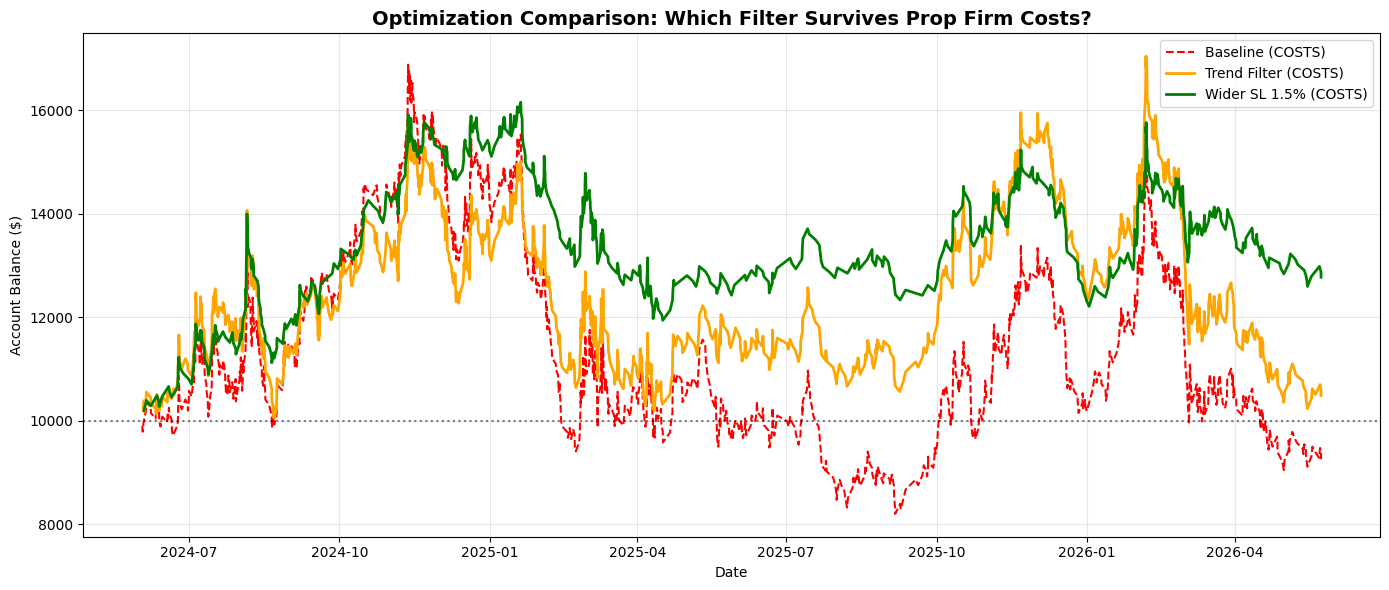

In [ ]:
# ============================================================
# 📊 STEP 6C: COMPARISON - BASELINE vs TREND vs WIDE SL
# ============================================================
print("\n" + "="*90)
print("📈 OPTIMIZATION COMPARISON: Which Filter Survives Costs Best?")
print("="*90)

# Gather all cost-adjusted results for direct comparison
all_cost_results = [
    {
        'Optimization': 'Baseline (No Filter)',
        'Net_Profit': metrics_12_cost['Net_Profit'],
        'Total_Trades': metrics_12_cost['Total_Trades'],
        'Win_Rate': f"{metrics_12_cost['Win_Rate']:.1f}%",
        'Profit_Factor': f"{metrics_12_cost['Profit_Factor']:.2f}",
        'Total_Costs': metrics_12_cost['Total_Costs']
    },
    {
        'Optimization': 'Trend Filter (200 EMA)',
        'Net_Profit': metrics_trend_cost['Net_Profit'],
        'Total_Trades': metrics_trend_cost['Total_Trades'],
        'Win_Rate': f"{metrics_trend_cost['Win_Rate']:.1f}%",
        'Profit_Factor': f"{metrics_trend_cost['Profit_Factor']:.2f}",
        'Total_Costs': metrics_trend_cost['Total_Costs']
    },
    {
        'Optimization': 'Wider Stop Loss (1.5%)',
        'Net_Profit': metrics_sl_cost['Net_Profit'],
        'Total_Trades': metrics_sl_cost['Total_Trades'],
        'Win_Rate': f"{metrics_sl_cost['Win_Rate']:.1f}%",
        'Profit_Factor': f"{metrics_sl_cost['Profit_Factor']:.2f}",
        'Total_Costs': metrics_sl_cost['Total_Costs']
    }
]

comp_df = pd.DataFrame(all_cost_results)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if isinstance(x, float) else str(x))
print(comp_df.to_string(index=False))
print("="*90)

# Plot equity curves for all three cost-adjusted tests
plt.figure(figsize=(14, 6))

# Baseline
if not results['1:2_Cost'].empty:
    eq_base = INITIAL_CAPITAL + results['1:2_Cost']['Net_PnL'].cumsum()
    plt.plot(results['1:2_Cost']['Exit_Date'], eq_base, label='Baseline (COSTS)', color='red', linestyle='--', linewidth=1.5)

# Trend Filter
if not results_trend['Trend_1:2_Cost'].empty:
    eq_trend = INITIAL_CAPITAL + results_trend['Trend_1:2_Cost']['Net_PnL'].cumsum()
    plt.plot(results_trend['Trend_1:2_Cost']['Exit_Date'], eq_trend, label='Trend Filter (COSTS)', color='orange', linewidth=2)

# Wider SL
if not results_sl['WideSL_1:2_Cost'].empty:
    eq_sl = INITIAL_CAPITAL + results_sl['WideSL_1:2_Cost']['Net_PnL'].cumsum()
    plt.plot(results_sl['WideSL_1:2_Cost']['Exit_Date'], eq_sl, label='Wider SL 1.5% (COSTS)', color='green', linewidth=2)

plt.axhline(INITIAL_CAPITAL, color='black', linestyle=':', alpha=0.5)
plt.title('Optimization Comparison: Which Filter Survives Prop Firm Costs?', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Account Balance ($)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 📥 STEP 1: LOAD 15-MINUTE DATA
# ============================================================
print("📥 Fetching 15-minute BTC data...")

# Adjust START_DATE for 15m interval as yfinance only supports ~60 days for this interval
# Make sure to import `timedelta` from `datetime` if not already imported in the global config cell
from datetime import date, timedelta

# Calculate a start date roughly 60 days ago from the END_DATE
# Ensure END_DATE is a datetime.date object before subtraction
current_end_date = date.today()
start_date_15m = (current_end_date - timedelta(days=59)).strftime('%Y-%m-%d')

df_15m = yf.download(SYMBOL, start=start_date_15m, end=END_DATE, interval='15m')

if df_15m.empty:
    raise ValueError("No 15m data found. Check dates or symbol.")

# Clean column names (same logic as 1h data)
if isinstance(df_15m.columns, pd.MultiIndex):
    df_15m.columns = ['_'.join(col).strip() for col in df_15m.columns.values]
else:
    df_15m.columns = [str(col) for col in df_15m.columns.values]

# Ensure standard OHLCV columns exist
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    match = [c for c in df_15m.columns if col in c]
    if match: df_15m[col] = df_15m[match[0]]

df_15m.dropna(inplace=True)
df_15m.reset_index(inplace=True)
if 'index' in df_15m.columns:
    df_15m.rename(columns={'index': 'Datetime'}, inplace=True)

print(f"✅ 15m Data Loaded: {len(df_15m)} candles from {df_15m['Datetime'].min().date()} to {df_15m['Datetime'].max().date()}")
print(f"⚠️ Note: 15m data has ~4x more candles than 1h → expect ~4x more trades")

📥 Fetching 15-minute BTC data...


[*********************100%***********************]  1 of 1 completed

✅ 15m Data Loaded: 5658 candles from 2026-03-27 to 2026-05-24
⚠️ Note: 15m data has ~4x more candles than 1h → expect ~4x more trades


In [ ]:
# ============================================================
# 📊 STEP 2: INDICATOR CALCULATION (15m Data)
# ============================================================
print("📈 Calculating EMAs on 15m data...")

df_15m['EMA_9'] = df_15m['Close'].ewm(span=EMA_FAST, adjust=False).mean()
df_15m['EMA_21'] = df_15m['Close'].ewm(span=EMA_MEDIUM, adjust=False).mean()
df_15m['EMA_55'] = df_15m['Close'].ewm(span=EMA_SLOW, adjust=False).mean()

# Drop initial NaNs where EMA_55 is undefined
df_15m.dropna(subset=['EMA_55'], inplace=True)
df_15m.reset_index(drop=True, inplace=True)

print(f"✅ Indicators Ready. Valid 15m Candles: {len(df_15m)}")

📈 Calculating EMAs on 15m data...
✅ Indicators Ready. Valid 15m Candles: 5658


In [ ]:
# ============================================================
# 🧠 STEP 3: SIGNAL GENERATION (15m, Shifted)
# ============================================================
print("🧠 Generating Signals on 15m data (Shifted)...")

buy_condition = (df_15m['EMA_9'] > df_15m['EMA_21']) & (df_15m['EMA_21'] > df_15m['EMA_55'])
sell_condition = (df_15m['EMA_9'] < df_15m['EMA_21']) & (df_15m['EMA_21'] < df_15m['EMA_55'])

# Shift signals to prevent look-ahead bias
df_15m['Signal_Buy'] = buy_condition.shift(1)
df_15m['Signal_Sell'] = sell_condition.shift(1)

df_15m.dropna(subset=['Signal_Buy', 'Signal_Sell'], inplace=True)
df_15m.reset_index(drop=True, inplace=True)

print(f"✅ 15m Signals Generated. Buy: {df_15m['Signal_Buy'].sum()}, Sell: {df_15m['Signal_Sell'].sum()}")

🧠 Generating Signals on 15m data (Shifted)...
✅ 15m Signals Generated. Buy: 2381, Sell: 2051


In [ ]:
# ============================================================
# 🤖 STEP 4: RUN OPTIMIZATION 4 (15m Timeframe, Base Params)
# ============================================================
print(" Running Optimization 4: 15m Timeframe with Base Parameters (1:2 RR, 1% SL)...")

# Create independent copies
df_15m_raw = df_15m.copy()
df_15m_cost = df_15m.copy()

results_15m = {}

# 1. 15m + Base Params + NO Costs
results_15m['15m_Base_Raw'], metrics_15m_raw = run_optimization_test(
    df_15m_raw,
    rr_ratio=2.0,      # Base 1:2 RR
    sl_pct=0.01,       # Base 1% SL
    apply_costs=False,
    test_name="15m Base Params (RAW)"
)

# 2. 15m + Base Params + WITH Costs
results_15m['15m_Base_Cost'], metrics_15m_cost = run_optimization_test(
    df_15m_cost,
    rr_ratio=2.0,
    sl_pct=0.01,
    apply_costs=True,
    test_name="15m Base Params (COSTS)"
)

print("✅ 15m timeframe tests complete.")

 Running Optimization 4: 15m Timeframe with Base Parameters (1:2 RR, 1% SL)...
✅ 15m timeframe tests complete.



📈 OPTIMIZATION 4 RESULTS: 15m Timeframe vs 1h Baseline (WITH COSTS)
        Timeframe  Net_Profit  Total_Trades Win_Rate Profit_Factor  Total_Costs Avg_Trade
1-Hour (Baseline)     -745.03          1746    35.9%          0.99    13,945.03    $-0.43
15-Minute (Opt 4)   -1,420.31            91    30.8%          0.79       720.31   $-15.61


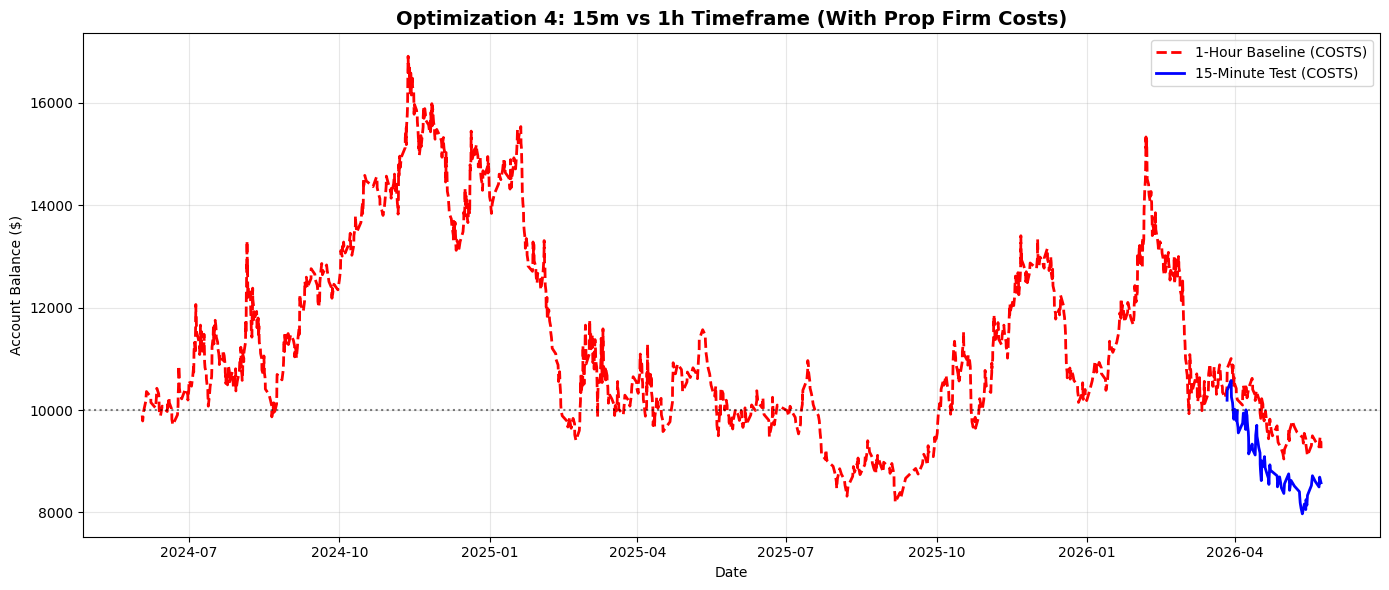

In [ ]:
# ============================================================
# 📊 STEP 5: ANALYSIS - 15m vs 1h (Cost-Adjusted Comparison)
# ============================================================
print("\n" + "="*80)
print("📈 OPTIMIZATION 4 RESULTS: 15m Timeframe vs 1h Baseline (WITH COSTS)")
print("="*80)

# Compare only cost-adjusted results (the real test)
comparison_data = [
    {
        'Timeframe': '1-Hour (Baseline)',
        'Net_Profit': metrics_12_cost['Net_Profit'],
        'Total_Trades': metrics_12_cost['Total_Trades'],
        'Win_Rate': f"{metrics_12_cost['Win_Rate']:.1f}%",
        'Profit_Factor': f"{metrics_12_cost['Profit_Factor']:.2f}",
        'Total_Costs': metrics_12_cost['Total_Costs'],
        'Avg_Trade': f"${metrics_12_cost['Avg_Trade']:.2f}"
    },
    {
        'Timeframe': '15-Minute (Opt 4)',
        'Net_Profit': metrics_15m_cost['Net_Profit'],
        'Total_Trades': metrics_15m_cost['Total_Trades'],
        'Win_Rate': f"{metrics_15m_cost['Win_Rate']:.1f}%",
        'Profit_Factor': f"{metrics_15m_cost['Profit_Factor']:.2f}",
        'Total_Costs': metrics_15m_cost['Total_Costs'],
        'Avg_Trade': f"${metrics_15m_cost['Avg_Trade']:.2f}"
    }
]

comp_df = pd.DataFrame(comparison_data)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if isinstance(x, (int, float)) else str(x))
print(comp_df.to_string(index=False))
print("="*80)

# Plot equity curves for direct visual comparison
plt.figure(figsize=(14, 6))

# 1h Baseline (Costs)
if not results['1:2_Cost'].empty:
    eq_1h = INITIAL_CAPITAL + results['1:2_Cost']['Net_PnL'].cumsum()
    plt.plot(results['1:2_Cost']['Exit_Date'], eq_1h, label='1-Hour Baseline (COSTS)', color='red', linestyle='--', linewidth=2)

# 15m Test (Costs)
if not results_15m['15m_Base_Cost'].empty:
    eq_15m = INITIAL_CAPITAL + results_15m['15m_Base_Cost']['Net_PnL'].cumsum()
    plt.plot(results_15m['15m_Base_Cost']['Exit_Date'], eq_15m, label='15-Minute Test (COSTS)', color='blue', linewidth=2)

plt.axhline(INITIAL_CAPITAL, color='black', linestyle=':', alpha=0.5)
plt.title('Optimization 4: 15m vs 1h Timeframe (With Prop Firm Costs)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Account Balance ($)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import date
import warnings
warnings.filterwarnings('ignore')

SYMBOL = 'BTC-USD'
START_DATE = '2024-06-01'
END_DATE = date.today().strftime('%Y-%m-%d')
INITIAL_CAPITAL = 10000.0
RISK_PERCENT = 0.01  # Fixed 1% risk per trade

COMMISSION_PCT = 0.0006
SPREAD_PCT = 0.0003
SLIPPAGE_PCT = 0.0002

print("️ Config Loaded: 1% Risk, ATR Stops, 1H Data")

️ Config Loaded: 1% Risk, ATR Stops, 1H Data


In [ ]:
# ============================================================
# 📊 STEP 1: INDICATORS + ATR CALCULATION
# ============================================================
print("📥 Fetching 1H data & calculating indicators...")
df = yf.download(SYMBOL, start=START_DATE, end=END_DATE, interval='1h')

if df.empty: raise ValueError("No data found.")
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ['_'.join(col).strip() for col in df.columns.values]
else:
    df.columns = [str(col) for col in df.columns.values]

for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    match = [c for c in df.columns if col in c]
    if match: df[col] = df[match[0]]

df.dropna(inplace=True)
df.reset_index(inplace=True)
if 'index' in df.columns: df.rename(columns={'index': 'Datetime'}, inplace=True)

# EMAs for signals
df['EMA_9'] = df['Close'].ewm(span=9, adjust=False).mean()
df['EMA_21'] = df['Close'].ewm(span=21, adjust=False).mean()
df['EMA_55'] = df['Close'].ewm(span=55, adjust=False).mean()

# ATR Calculation (14-period)
high, low, close = df['High'], df['Low'], df['Close']
tr1 = high - low
tr2 = abs(high - close.shift(1))
tr3 = abs(low - close.shift(1))
df['ATR'] = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1).rolling(window=14).mean()

df.dropna(subset=['EMA_55', 'ATR'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Data Ready: {len(df)} candles. Avg ATR: ${df['ATR'].mean():.2f}")

[*********************100%***********************]  1 of 1 completed

📥 Fetching 1H data & calculating indicators...
✅ Data Ready: 17306 candles. Avg ATR: $500.05


In [ ]:
# ============================================================
# 🧠 STEP 2: SIGNAL GENERATION (SHIFTED)
# ============================================================
print("🧠 Generating Signals (Shifted)...")

buy_cond = (df['EMA_9'] > df['EMA_21']) & (df['EMA_21'] > df['EMA_55'])
sell_cond = (df['EMA_9'] < df['EMA_21']) & (df['EMA_21'] < df['EMA_55'])

df['Signal_Buy'] = buy_cond.shift(1)
df['Signal_Sell'] = sell_cond.shift(1)

df.dropna(subset=['Signal_Buy', 'Signal_Sell'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"✅ Signals Generated. Buy: {df['Signal_Buy'].sum()}, Sell: {df['Signal_Sell'].sum()}")

🧠 Generating Signals (Shifted)...
✅ Signals Generated. Buy: 6984, Sell: 6417


In [ ]:
# ============================================================
#  STEP 3: ATR BACKTEST ENGINE
# ============================================================
def run_atr_test(df, atr_multiplier=2.0, rr_ratio=2.0, apply_costs=False, test_name="Test"):
    """
    Dynamic SL/TP based on ATR. Fixed 1% risk per trade.
    """
    trades = []
    in_trade = False
    trade_type = None
    entry_price = 0.0
    entry_date = None
    sl_price = 0.0
    tp_price = 0.0
    position_size = 0.0

    risk_amount = INITIAL_CAPITAL * RISK_PERCENT

    for i in range(len(df)):
        row = df.iloc[i]
        dt, o, h, l, atr = row['Datetime'], row['Open'], row['High'], row['Low'], row['ATR']

        # Safety fallback if ATR is 0
        if atr <= 0: atr = df['ATR'].median()

        # --- EXIT LOGIC ---
        if in_trade:
            exit_reason, exit_price = None, 0.0
            if trade_type == 'BUY':
                if l <= sl_price: exit_reason, exit_price = 'SL', sl_price
                elif h >= tp_price: exit_reason, exit_price = 'TP', tp_price
            else:
                if h >= sl_price: exit_reason, exit_price = 'SL', sl_price
                elif l <= tp_price: exit_reason, exit_price = 'TP', tp_price

            if exit_reason:
                gross_pnl = (exit_price - entry_price) * position_size if trade_type == 'BUY' else (entry_price - exit_price) * position_size
                costs = 0.0
                if apply_costs:
                    costs += (entry_price * position_size) * COMMISSION_PCT
                    costs += (entry_price * position_size) * np.random.uniform(0, SLIPPAGE_PCT * 2)
                net_pnl = gross_pnl - costs
                trades.append({'Date': dt, 'Gross': gross_pnl, 'Costs': costs, 'Net': net_pnl})
                in_trade = False

        # --- ENTRY LOGIC ---
        if not in_trade and (row['Signal_Buy'] or row['Signal_Sell']):
            in_trade = True
            trade_type = 'BUY' if row['Signal_Buy'] else 'SELL'

            # Apply spread if modeling costs
            entry_price = o * (1 + SPREAD_PCT) if apply_costs and trade_type == 'BUY' else \
                          o * (1 - SPREAD_PCT) if apply_costs else o
            entry_date = dt

            # Dynamic SL/TP from ATR
            sl_distance = atr * atr_multiplier
            tp_distance = sl_distance * rr_ratio

            if trade_type == 'BUY':
                sl_price = entry_price - sl_distance
                tp_price = entry_price + tp_distance
            else:
                sl_price = entry_price + sl_distance
                tp_price = entry_price - tp_distance

            # Position sizing: exactly 1% risk
            position_size = risk_amount / sl_distance

    if not trades: return pd.DataFrame(), {}
    trades_df = pd.DataFrame(trades)

    gross_profit = trades_df[trades_df['Net'] > 0]['Net'].sum()
    gross_loss = abs(trades_df[trades_df['Net'] < 0]['Net'].sum())

    metrics = {
        'Net_Profit': trades_df['Net'].sum(),
        'Total_Trades': len(trades_df),
        'Win_Rate': (trades_df['Net'] > 0).mean() * 100,
        'Profit_Factor': gross_profit / gross_loss if gross_loss > 0 else 0,
        'Total_Costs': trades_df['Costs'].sum(),
        'Avg_Trade': trades_df['Net'].mean()
    }
    return trades_df, metrics

In [ ]:
# ============================================================
#  STEP 4: RUN OPTIMIZATION 5 (ATR STOPS + 1% RISK)
# ============================================================
print(" Running Optimization 5: ATR-Based SL/TP (2x ATR, 1:2 RR, 1% Risk)...")

df_atr_raw = df.copy()
df_atr_cost = df.copy()

results_atr = {}

# 1. ATR + 1:2 RR + NO Costs
results_atr['ATR_Raw'], metrics_atr_raw = run_atr_test(
    df_atr_raw, atr_multiplier=2.0, rr_ratio=2.0, apply_costs=False, test_name="ATR Stops (RAW)"
)

# 2. ATR + 1:2 RR + WITH Costs
results_atr['ATR_Cost'], metrics_atr_cost = run_atr_test(
    df_atr_cost, atr_multiplier=2.0, rr_ratio=2.0, apply_costs=True, test_name="ATR Stops (COSTS)"
)

print("✅ ATR optimization tests complete.")

 Running Optimization 5: ATR-Based SL/TP (2x ATR, 1:2 RR, 1% Risk)...
✅ ATR optimization tests complete.



📈 OPTIMIZATION 5 RESULTS: ATR-Based Stops vs Baseline (WITH COSTS)
                  Strategy  Net_Profit  Total_Trades Win_Rate Profit_Factor  Total_Costs Avg_Trade
    Baseline (Fixed 1% SL)     -745.03          1746    35.9%          0.99    13,945.03    $-0.43
ATR Stops (2x ATR, 1:2 RR)   12,008.03           949    39.9%          1.20     6,791.97    $12.65


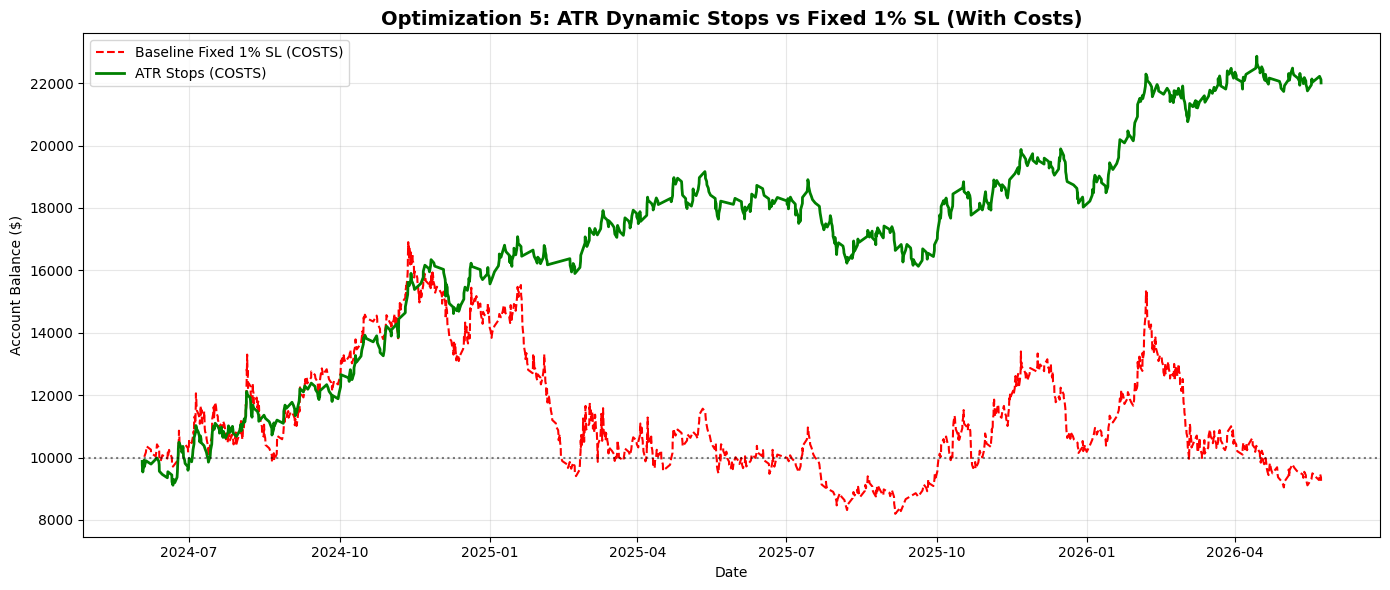

In [ ]:
# ============================================================
# 📊 STEP 5: ANALYSIS & VISUALIZATION
# ============================================================
print("\n" + "="*80)
print("📈 OPTIMIZATION 5 RESULTS: ATR-Based Stops vs Baseline (WITH COSTS)")
print("="*80)

comparison_data = [
    {
        'Strategy': 'Baseline (Fixed 1% SL)',
        'Net_Profit': metrics_12_cost['Net_Profit'],
        'Total_Trades': metrics_12_cost['Total_Trades'],
        'Win_Rate': f"{metrics_12_cost['Win_Rate']:.1f}%",
        'Profit_Factor': f"{metrics_12_cost['Profit_Factor']:.2f}",
        'Total_Costs': metrics_12_cost['Total_Costs'],
        'Avg_Trade': f"${metrics_12_cost['Avg_Trade']:.2f}"
    },
    {
        'Strategy': 'ATR Stops (2x ATR, 1:2 RR)',
        'Net_Profit': metrics_atr_cost['Net_Profit'],
        'Total_Trades': metrics_atr_cost['Total_Trades'],
        'Win_Rate': f"{metrics_atr_cost['Win_Rate']:.1f}%",
        'Profit_Factor': f"{metrics_atr_cost['Profit_Factor']:.2f}",
        'Total_Costs': metrics_atr_cost['Total_Costs'],
        'Avg_Trade': f"${metrics_atr_cost['Avg_Trade']:.2f}"
    }
]

comp_df = pd.DataFrame(comparison_data)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}' if isinstance(x, (int, float)) else str(x))
print(comp_df.to_string(index=False))
print("="*80)

# Plot equity curves
plt.figure(figsize=(14, 6))

if not results['1:2_Cost'].empty:
    eq_base = INITIAL_CAPITAL + results['1:2_Cost']['Net_PnL'].cumsum()
    plt.plot(results['1:2_Cost']['Exit_Date'], eq_base, label='Baseline Fixed 1% SL (COSTS)', color='red', linestyle='--')

if not results_atr['ATR_Cost'].empty:
    eq_atr = INITIAL_CAPITAL + results_atr['ATR_Cost']['Net'].cumsum()
    plt.plot(results_atr['ATR_Cost']['Date'], eq_atr, label='ATR Stops (COSTS)', color='green', linewidth=2)

plt.axhline(INITIAL_CAPITAL, color='black', linestyle=':', alpha=0.5)
plt.title('Optimization 5: ATR Dynamic Stops vs Fixed 1% SL (With Costs)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Account Balance ($)')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


📈 FINAL OPTIMIZATION COMPARISON (COST-ADJUSTED RESULTS)
                 Optimization Net_Profit  Total_Trades Win_Rate Profit_Factor Total_Costs Avg_Trade
       Baseline (Fixed 1% SL)   $-745.03          1746    35.9%          0.99  $13,945.03    $-0.43
                Opt 1: RR 1:3 $-1,222.13          1252    26.8%          0.99  $10,022.13    $-0.98
Opt 2: Trend Filter (200 EMA)    $481.88          1571    36.1%          1.00  $12,518.12     $0.31
       Opt 3: Wider SL (1.5%)  $2,773.14           811    36.3%          1.05   $4,326.86     $3.42
         Opt 4: 15m Timeframe $-1,420.31            91    30.8%          0.79     $720.31   $-15.61
  🏆 Opt 5: ATR Stops (2x ATR) $12,008.03           949    39.9%          1.20   $6,791.97    $12.65



,Optimization,Net_Profit,Total_Trades,Win_Rate,Profit_Factor,Total_Costs,Avg_Trade
0,Baseline (Fixed 1% SL),$-745.03,1746,35.9%,0.99,"$13,945.03",$-0.43
1,Opt 1: RR 1:3,"$-1,222.13",1252,26.8%,0.99,"$10,022.13",$-0.98
2,Opt 2: Trend Filter (200 EMA),$481.88,1571,36.1%,1.00,"$12,518.12",$0.31
3,Opt 3: Wider SL (1.5%),"$2,773.14",811,36.3%,1.05,"$4,326.86",$3.42
4,Opt 4: 15m Timeframe,"$-1,420.31",91,30.8%,0.79,$720.31,$-15.61
5,🏆 Opt 5: ATR Stops (2x ATR),"$12,008.03",949,39.9%,1.20,"$6,791.97",$12.65


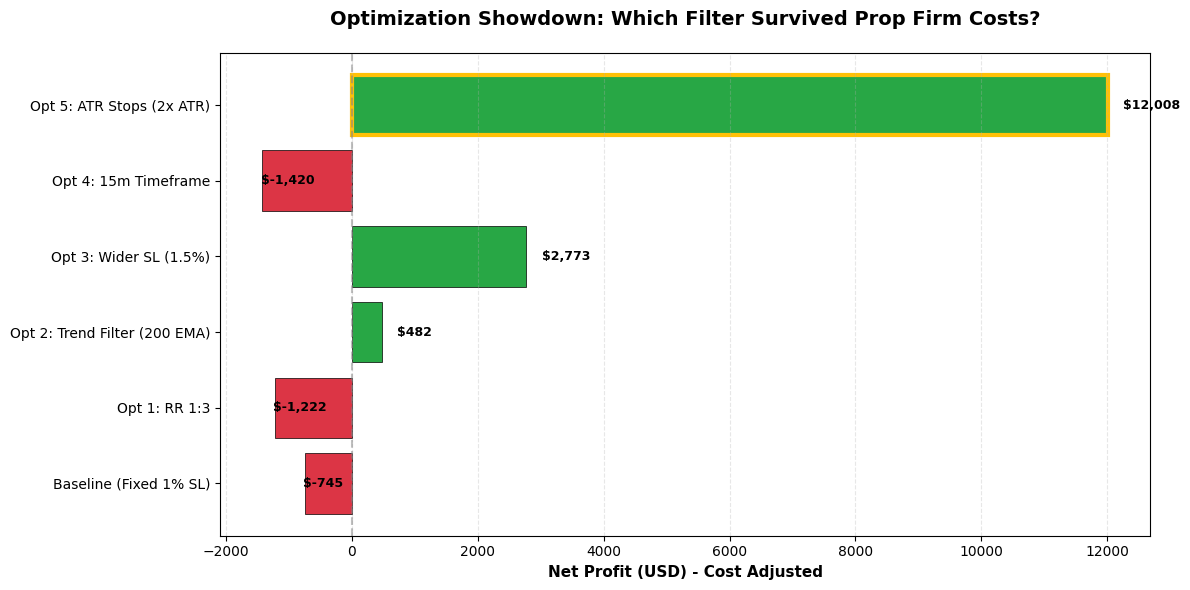

In [ ]:
# ============================================================
# 📊 FINAL COMPARISON TABLE GENERATOR
# Copy-paste this after running all optimization tests
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. GATHER ALL COST-ADJUSTED METRICS
# ============================================================
# These dictionaries should exist from your previous optimization cells:
# - metrics_12_cost: Baseline (Fixed 1% SL)
# - metrics_trend_cost: Trend Filter (200 EMA)
# - metrics_sl_cost: Wider Stop Loss (1.5%)
# - metrics_15m_cost: 15-Minute Timeframe
# - metrics_atr_cost: ATR-Based Stops (2x ATR)

comparison_data = [
    {
        'Optimization': 'Baseline (Fixed 1% SL)',
        'Net_Profit': metrics_12_cost['Net_Profit'],
        'Total_Trades': metrics_12_cost['Total_Trades'],
        'Win_Rate': metrics_12_cost['Win_Rate'],
        'Profit_Factor': metrics_12_cost['Profit_Factor'],
        'Total_Costs': metrics_12_cost['Total_Costs'],
        'Avg_Trade': metrics_12_cost['Avg_Trade']
    },
    {
        'Optimization': 'Opt 1: RR 1:3',
        'Net_Profit': metrics_13_cost['Net_Profit'],
        'Total_Trades': metrics_13_cost['Total_Trades'],
        'Win_Rate': metrics_13_cost['Win_Rate'],
        'Profit_Factor': metrics_13_cost['Profit_Factor'],
        'Total_Costs': metrics_13_cost['Total_Costs'],
        'Avg_Trade': metrics_13_cost['Avg_Trade']
    },
    {
        'Optimization': 'Opt 2: Trend Filter (200 EMA)',
        'Net_Profit': metrics_trend_cost['Net_Profit'],
        'Total_Trades': metrics_trend_cost['Total_Trades'],
        'Win_Rate': metrics_trend_cost['Win_Rate'],
        'Profit_Factor': metrics_trend_cost['Profit_Factor'],
        'Total_Costs': metrics_trend_cost['Total_Costs'],
        'Avg_Trade': metrics_trend_cost['Avg_Trade']
    },
    {
        'Optimization': 'Opt 3: Wider SL (1.5%)',
        'Net_Profit': metrics_sl_cost['Net_Profit'],
        'Total_Trades': metrics_sl_cost['Total_Trades'],
        'Win_Rate': metrics_sl_cost['Win_Rate'],
        'Profit_Factor': metrics_sl_cost['Profit_Factor'],
        'Total_Costs': metrics_sl_cost['Total_Costs'],
        'Avg_Trade': metrics_sl_cost['Avg_Trade']
    },
    {
        'Optimization': 'Opt 4: 15m Timeframe',
        'Net_Profit': metrics_15m_cost['Net_Profit'],
        'Total_Trades': metrics_15m_cost['Total_Trades'],
        'Win_Rate': metrics_15m_cost['Win_Rate'],
        'Profit_Factor': metrics_15m_cost['Profit_Factor'],
        'Total_Costs': metrics_15m_cost['Total_Costs'],
        'Avg_Trade': metrics_15m_cost['Avg_Trade']
    },
    {
        'Optimization': '🏆 Opt 5: ATR Stops (2x ATR)',
        'Net_Profit': metrics_atr_cost['Net_Profit'],
        'Total_Trades': metrics_atr_cost['Total_Trades'],
        'Win_Rate': metrics_atr_cost['Win_Rate'],
        'Profit_Factor': metrics_atr_cost['Profit_Factor'],
        'Total_Costs': metrics_atr_cost['Total_Costs'],
        'Avg_Trade': metrics_atr_cost['Avg_Trade']
    }
]

# ============================================================
# 2. CREATE & FORMAT THE TABLE
# ============================================================
comp_df = pd.DataFrame(comparison_data)

# Format columns for professional display
comp_df['Net_Profit'] = comp_df['Net_Profit'].apply(lambda x: f"${x:,.2f}")
comp_df['Total_Costs'] = comp_df['Total_Costs'].apply(lambda x: f"${x:,.2f}")
comp_df['Avg_Trade'] = comp_df['Avg_Trade'].apply(lambda x: f"${x:.2f}")
comp_df['Win_Rate'] = comp_df['Win_Rate'].apply(lambda x: f"{x:.1f}%")
comp_df['Profit_Factor'] = comp_df['Profit_Factor'].apply(lambda x: f"{x:.2f}")

# Reorder columns for logical flow
comp_df = comp_df[[
    'Optimization',
    'Net_Profit',
    'Total_Trades',
    'Win_Rate',
    'Profit_Factor',
    'Total_Costs',
    'Avg_Trade'
]]

# ============================================================
# 3. DISPLAY WITH CONDITIONAL FORMATTING (For Notebook/Video)
# ============================================================
def highlight_best(row):
    """Highlight best Net_Profit and Profit_Factor in green, worst in red"""
    styles = [''] * len(row)
    # Find numeric Net_Profit for comparison
    numeric_profits = [float(p.replace('$','').replace(',','')) for p in comp_df['Net_Profit']]
    max_profit_idx = numeric_profits.index(max(numeric_profits))
    min_profit_idx = numeric_profits.index(min(numeric_profits))

    if row.name == max_profit_idx:
        styles[1] = 'background-color: #d4edda; color: #155724; font-weight: bold'  # Green for best profit
    elif row.name == min_profit_idx and min(numeric_profits) < 0:
        styles[1] = 'background-color: #f8d7da; color: #721c24'  # Red for worst loss

    return styles

# Display the styled table
styled_table = comp_df.style.apply(highlight_best, axis=1)\
    .set_properties(**{'text-align': 'center'})\
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-weight', 'bold')]},
        {'selector': 'td', 'props': [('padding', '8px')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f8f9fa')]}
    ])

print("\n" + "="*100)
print("📈 FINAL OPTIMIZATION COMPARISON (COST-ADJUSTED RESULTS)")
print("="*100)
print(comp_df.to_string(index=False))
print("="*100 + "\n")

# For Jupyter/Colab: display the styled version
try:
    display(styled_table)
except:
    pass  # Fallback if display() not available

# ============================================================
# 4. OPTIONAL: EXPORT TO CSV FOR VIDEO DESCRIPTION
# ============================================================
# Uncomment to save
# comp_df.to_csv('optimization_comparison.csv', index=False)
# print("✅ Table exported to 'optimization_comparison.csv'")

# ============================================================
# 5. VISUALIZATION: BAR CHART OF NET PROFIT (For Video Thumbnail/B-Roll)
# ============================================================
plt.figure(figsize=(12, 6))

# Extract numeric values for plotting
names = comp_df['Optimization'].str.replace('🏆 ', '')
profits = [float(p.replace('$','').replace(',','')) for p in comp_df['Net_Profit']]

# Color bars: green for positive, red for negative
colors = ['#28a745' if p > 0 else '#dc3545' for p in profits]

bars = plt.barh(names, profits, color=colors, edgecolor='black', linewidth=0.5)

# Add value labels on bars
for i, (bar, profit) in enumerate(zip(bars, profits)):
    label = f"${profit:,.0f}"
    plt.text(profit + (max(profits)*0.02 if profit > 0 else min(profits)*0.02),
             i, label, va='center', fontsize=9, fontweight='bold')

plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('Net Profit (USD) - Cost Adjusted', fontsize=11, fontweight='bold')
plt.title('Optimization Showdown: Which Filter Survived Prop Firm Costs?', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()

# Highlight the winner with a border
if profits:
    winner_idx = profits.index(max(profits))
    bars[winner_idx].set_edgecolor('#ffc107')
    bars[winner_idx].set_linewidth(3)

plt.show()

In [ ]:
rember trade systematic verify everything .
Dont forget to like subscribe thanks